In [119]:
import torch
from cryosim.atom import (
    kirkland_atomic_potential_3d,
    kirkland_atomic_potential_3d_fourier,
)
from cryosim.plotting_tools import plot3d
from cryosim.fft_tools import fftn
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from matplotlib.colors import PowerNorm
import matplotlib.ticker as ticker

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [98]:
n = 500
x = torch.linspace(-0.1, 0.1, n)
dx = x[1] - x[0]
X, Y, Z = torch.meshgrid(x, x, x, indexing="ij")
R = torch.sqrt(X**2 + Y**2 + Z**2)
k = torch.fft.fftshift(torch.fft.fftfreq(n, dx))
dk = k[1] - k[0]
Kx, Ky, Kz = torch.meshgrid(k, k, k, indexing="ij")
K = torch.sqrt(Kx**2 + Ky**2 + Kz**2)

In [99]:
o = kirkland_atomic_potential_3d(8, R)
c = kirkland_atomic_potential_3d(6, R)
h = kirkland_atomic_potential_3d(1, R)
n = kirkland_atomic_potential_3d(7, R)
s = kirkland_atomic_potential_3d(16, R)

In [140]:
pots = [h, c, n, o, s]
labels = [
    r"Hydrogen ($Z = 1$)",
    r"Carbon ($Z = 6$)",
    r"Nitrogen ($Z = 7$)",
    r"Oxygen ($Z = 8$)",
    r"Sulfur ($Z = 16$)",
]

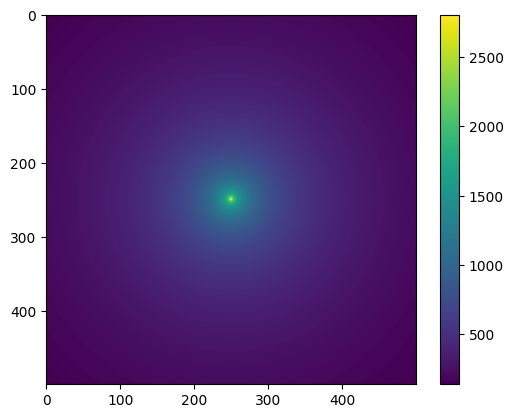

In [109]:
plt.imshow(s.sum(0) * dx)
plt.colorbar()

In [148]:
40e-15

4e-14

In [146]:
0.0004 * 1e-10

4.0000000000000006e-14

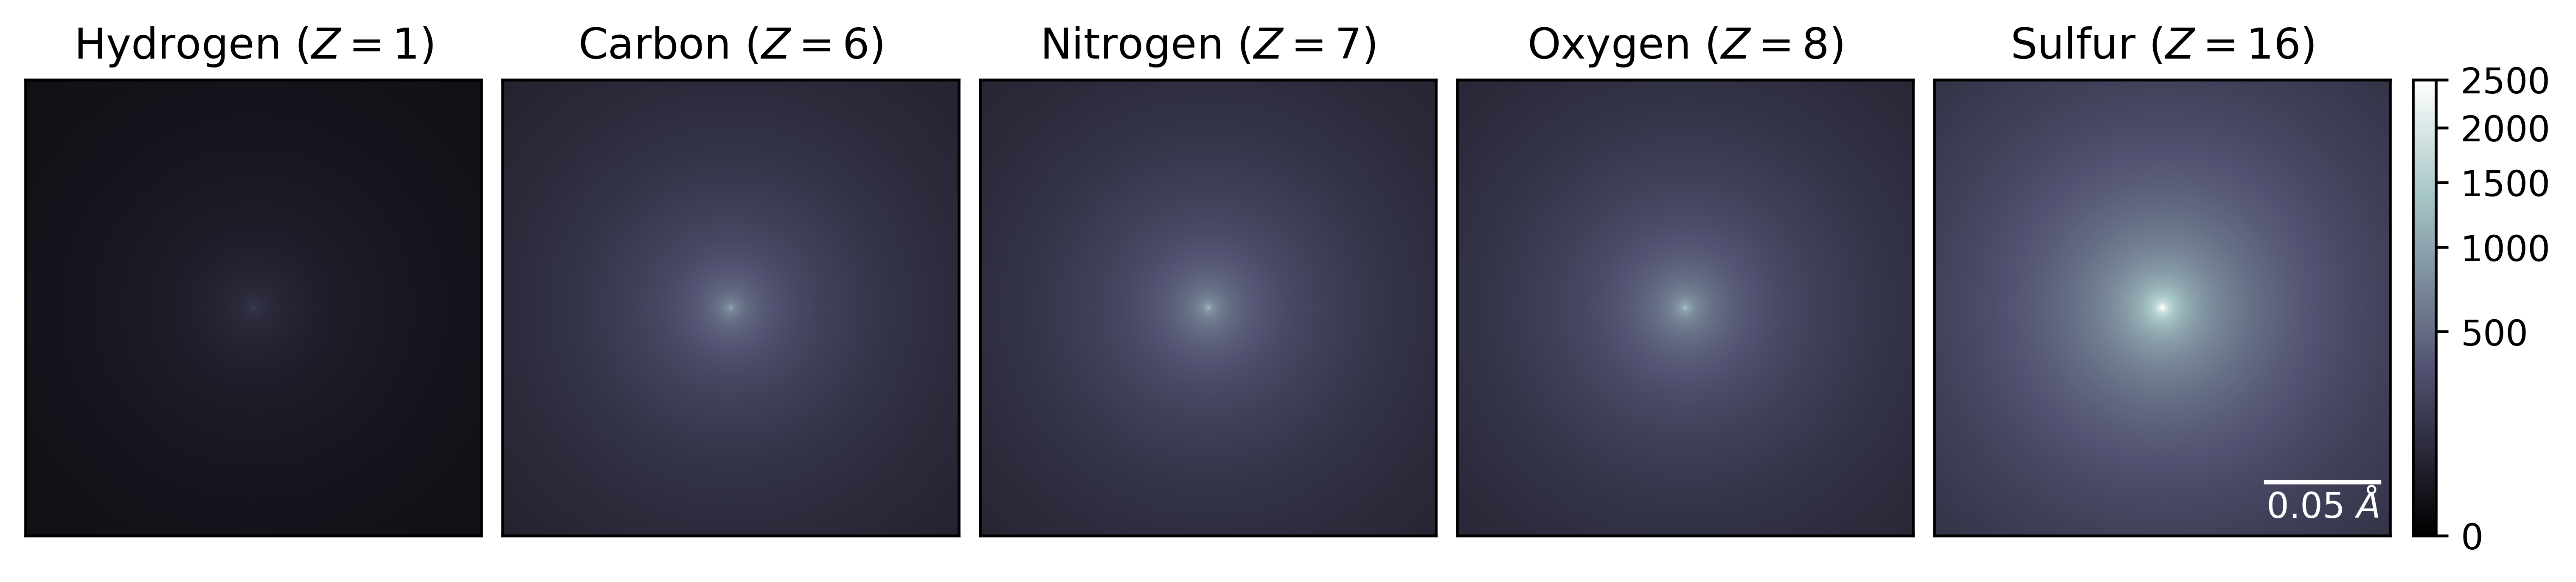

In [142]:
fig, axes = plt.subplots(1, 5, dpi=600, constrained_layout=True, figsize=(10, 3))
[ax.set(xticks=[], yticks=[]) for ax in axes.ravel()]
cmap = "bone"
vmax = 2500

for i in range(5):
    ax = axes[i]
    im = ax.imshow(
        pots[i].sum(0) * dx,
        cmap=cmap,
        # norm=LogNorm(vmin=1, vmax=vmax),
        norm=PowerNorm(gamma=0.5, vmin=0, vmax=vmax),
        # vmin=0,
        # vmax=vmax,
    )
    ax.set_title(labels[i])

    if i == 4:
        cbar = fig.colorbar(im, ax=ax, shrink=0.614)
        # This forces the ticks to be spaced linearly regardless of the Norm
        cbar.locator = ticker.LinearLocator(numticks=6)
        cbar.update_ticks()

        # ---- add scalebar (no font_manager) ----
        pixel_size = dx  # nm per pixel (change this)
        bar_length = 125  # pixels
        label = f"{bar_length * pixel_size:.2f} $\AA$"

        scalebar = AnchoredSizeBar(
            ax.transData,
            bar_length,
            label,
            loc="lower right",
            pad=0.2,
            color="white",
            frameon=False,
            size_vertical=1,
        )

        ax.add_artist(scalebar)

plt.show()

In [5]:
atom_number = 2
a0 = 0.529  # Bohr radius, [Angstrom]
e = 14.4  # electron charge, [V-Angstrom]
oxygen = kirkland_atomic_potential_3d(atom_number, R)
oxygen_f = kirkland_atomic_potential_3d_fourier(atom_number, K)

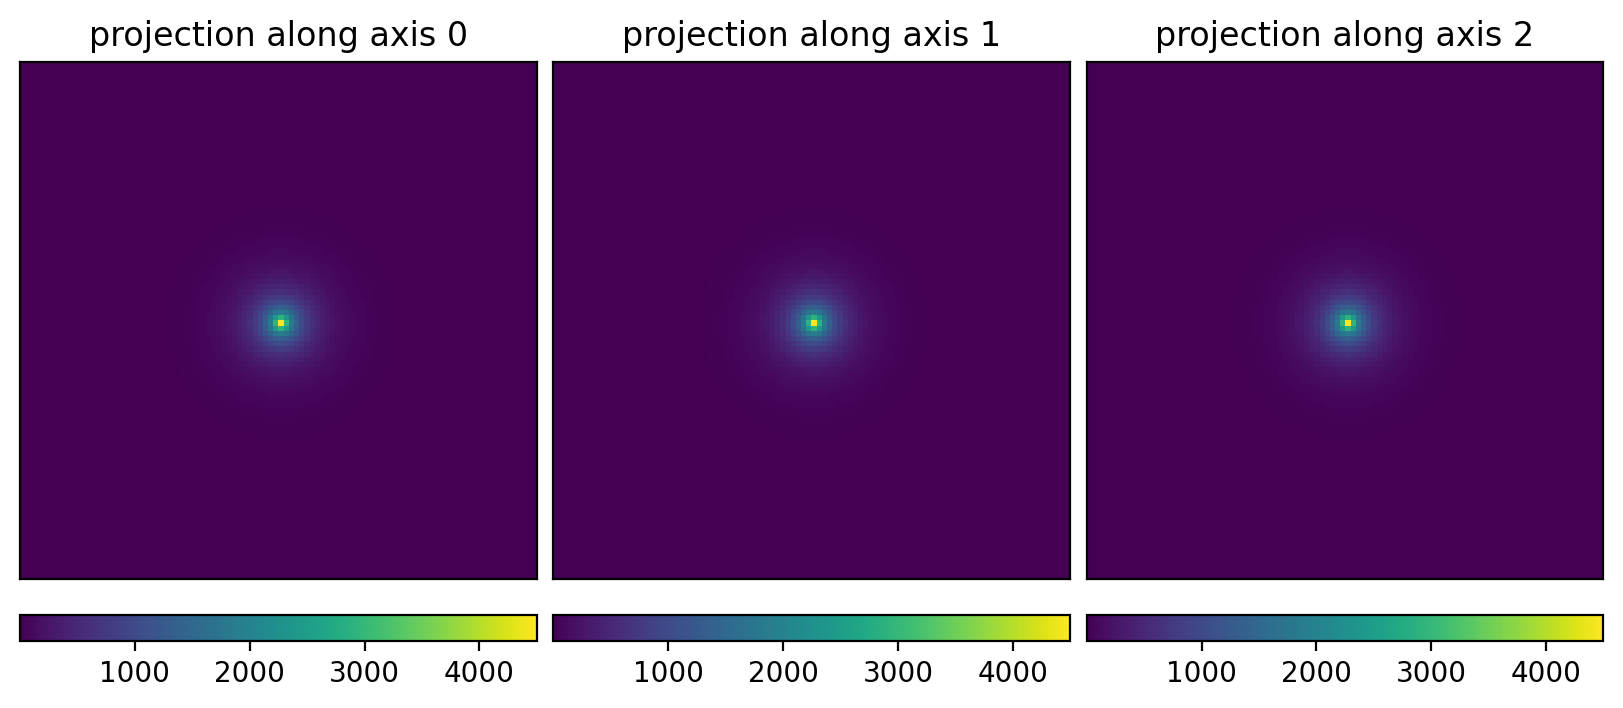

In [140]:
plot3d(torch.abs(fftn(oxygen_f)) * 2 * torch.pi * dk**3 * a0 * e)

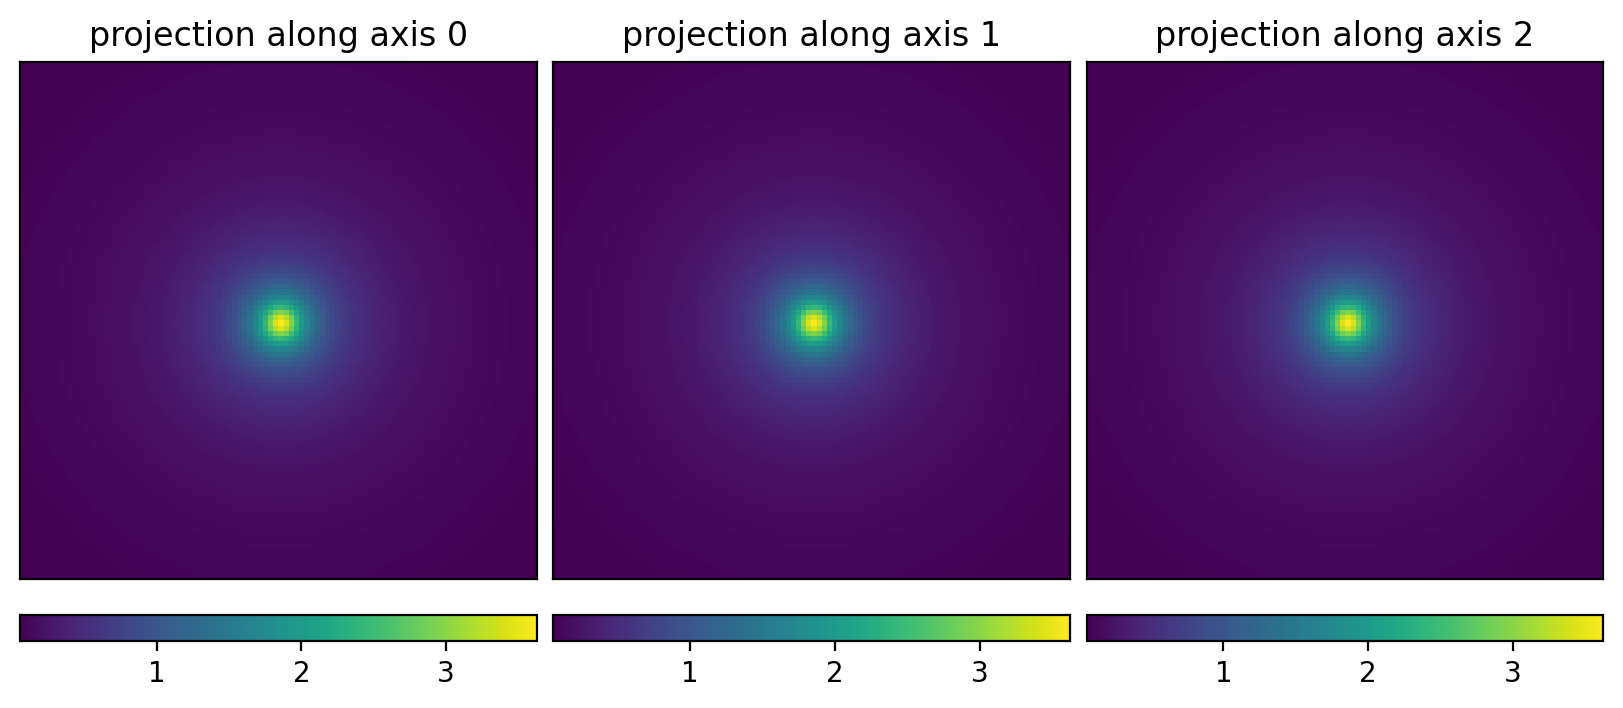

In [141]:
plot3d(torch.abs(oxygen_f))

In [142]:
dx

tensor(0.0404)

In [50]:
# Example: 3D Gaussian
sigma = 0.5
f = torch.exp(-(R**2) / (2 * sigma**2))

# Numerical FFT
F = fftn(f)

# Scale correction
F = F * dx**3

In [51]:
F_anal = (2 * torch.pi * sigma**2) ** 1.5 * torch.exp(
    -2 * torch.pi**2 * sigma**2 * K**2
)

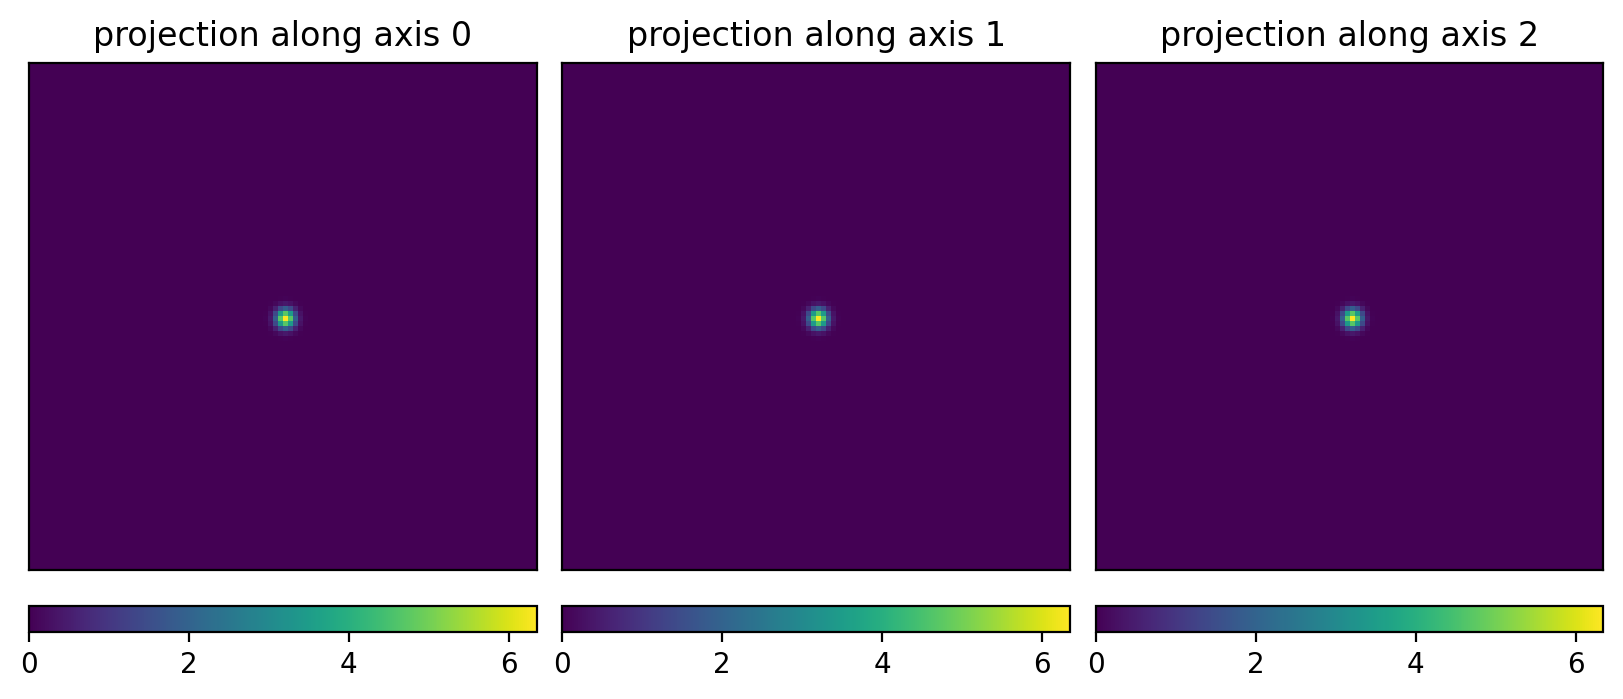

In [53]:
plot3d(torch.abs(F))

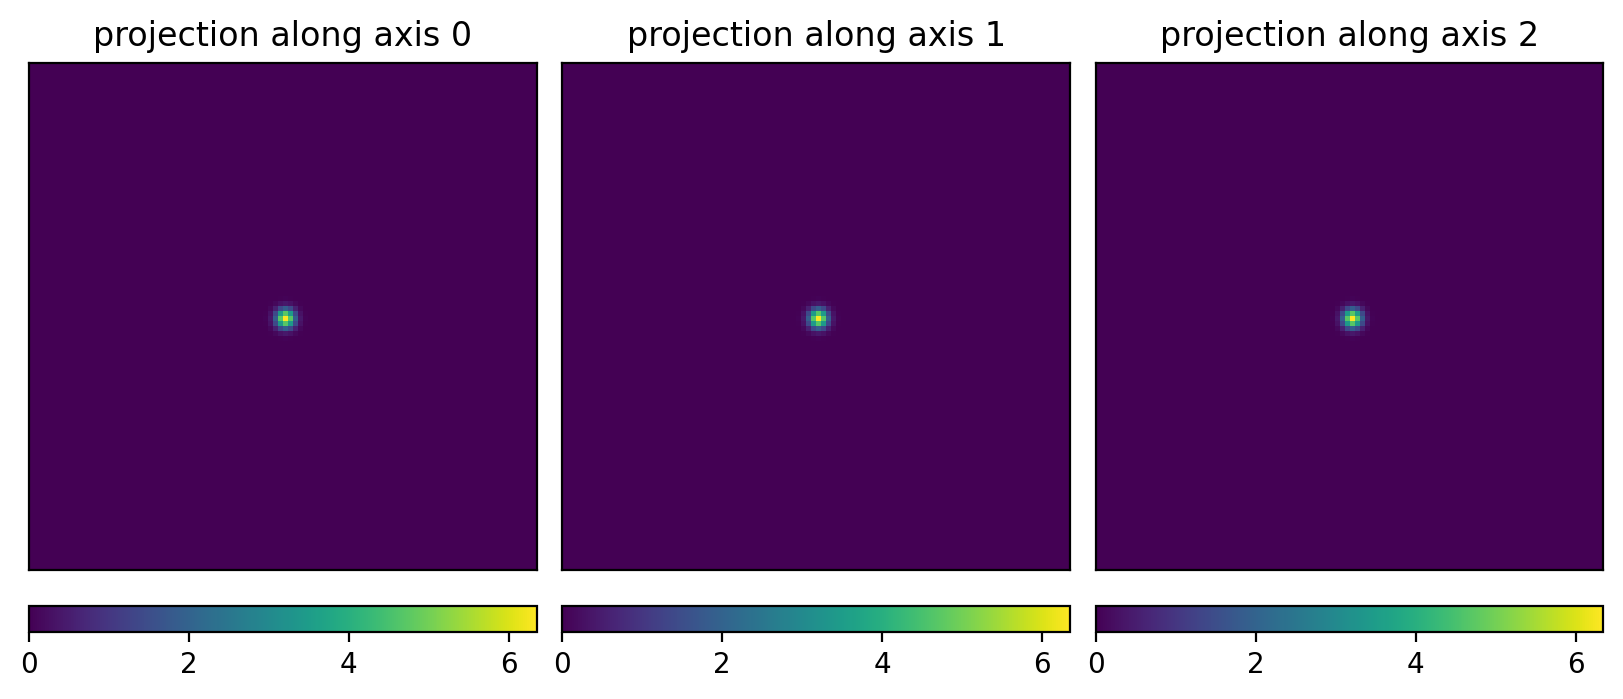

In [54]:
plot3d(F_anal)

Minimal padding per side: 167 pixels


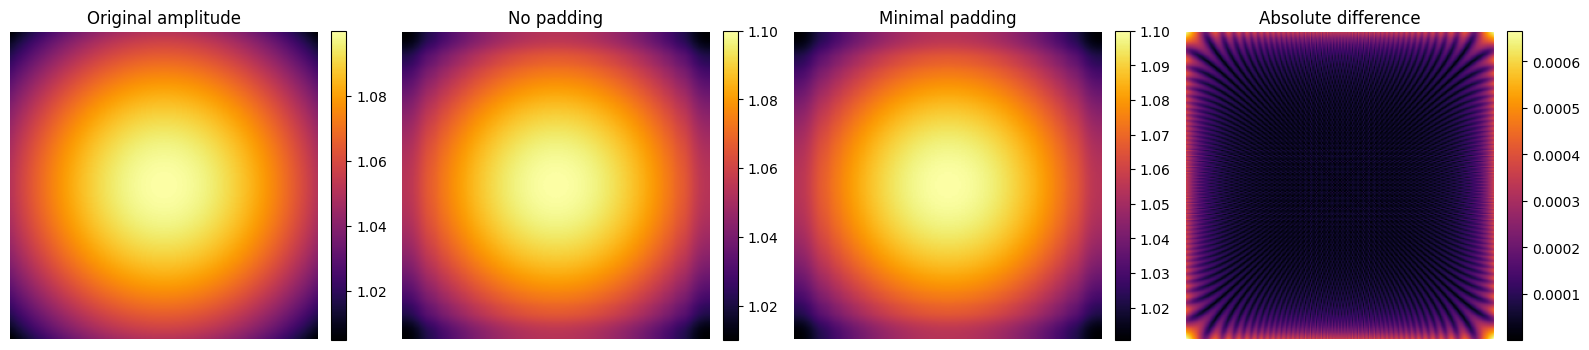

In [159]:
import torch
import torch.fft as fft
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math


# ---------------------------
# Fresnel propagation functions
# ---------------------------
def fresnel_kernel(N, dx, wavelength, z, device):
    """Compute the angular spectrum transfer function for Fresnel propagation"""
    fx = torch.fft.fftfreq(N, d=dx).to(device)
    FX, FY = torch.meshgrid(fx, fx, indexing="ij")
    H = torch.exp(-1j * torch.pi * wavelength * z * (FX**2 + FY**2))
    return fft.fftshift(H)


def fresnel_propagate(u0, wavelength, dx, z):
    """Propagate a field using FFT-based Fresnel propagation"""
    N = u0.shape[0]
    device = u0.device
    H = fresnel_kernel(N, dx, wavelength, z, device)
    U = fft.fftshift(fft.fft2(fft.ifftshift(u0)))
    U2 = U * H
    u2 = fft.fftshift(fft.ifft2(fft.ifftshift(U2)))
    return u2


def compute_min_padding(z, wavelength, dx):
    """Compute minimum padding in pixels based on Fresnel spread"""
    pad = z * wavelength / (2 * dx * dx)
    return int(math.ceil(pad))


# ---------------------------
# User parameters
# ---------------------------
N = 256  # image size
dx = 8e-6  # pixel size (meters)
wavelength = 532e-9  # wavelength (meters)
z = 0.04  # propagation distance (meters)

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Example 2D image (Gaussian + nonzero edges)
# ---------------------------
x = torch.linspace(-1, 1, N)
X, Y = torch.meshgrid(x, x, indexing="ij")
image = torch.exp(-((X**2 + Y**2) / 20)) + 0.1  # nonzero edges
field = image.to(device, dtype=torch.complex64)

# ---------------------------
# Non-padded propagation
# ---------------------------
field_out_nopad = fresnel_propagate(field, wavelength, dx, z)

# ---------------------------
# Minimal padded propagation
# ---------------------------
pad_px = compute_min_padding(z, wavelength, dx)
print(f"Minimal padding per side: {pad_px} pixels")

field_padded = torch.squeeze(
    F.pad(field.unsqueeze(0), (pad_px, pad_px, pad_px, pad_px), mode="reflect")
)
field_out_padded = fresnel_propagate(field_padded, wavelength, dx, z)
# Crop back to original size
field_out_padded_crop = field_out_padded[pad_px : pad_px + N, pad_px : pad_px + N]

# ---------------------------
# Difference map
# ---------------------------
diff = torch.abs(field_out_padded_crop - field_out_nopad)

# ---------------------------
# Plot results
# ---------------------------
field_cpu = field.abs().cpu().numpy()
nopad_cpu = field_out_nopad.abs().cpu().numpy()
padded_cpu = field_out_padded_crop.abs().cpu().numpy()
diff_cpu = diff.cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
titles = ["Original amplitude", "No padding", "Minimal padding", "Absolute difference"]
images = [field_cpu, nopad_cpu, padded_cpu, diff_cpu]

for ax, img, title in zip(axs, images, titles):
    im = ax.imshow(img, cmap="inferno")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()